# 3 — Memory benchmarks

Week 2 built three tiers of memory: **semantic** (free-form facts), **episodic** (past-thread summaries), and **procedural** (learned skills extracted by reflection). This notebook asks the obvious follow-up: *do they actually help?*

We'll separate two questions that often get conflated:

1. **Does the plumbing work?** Programmatic retrieval metrics — `recall@k`, `MRR` — over small gold sets. No LLM judge needed; either the right record came back or it didn't (Sections **A** and **B**).
2. **Does memory change user-visible quality?** End-to-end task suites scored by the **optimized DSPy judge from notebook 2**. We compare conditions: stateless vs. semantic-injection (Section **C**), and no-skill vs. with-skill on procedural transfer tasks (Section **D**).

The procedural section is the most interesting one — it tests the *full learning loop*: a conversation teaches a preference, `reflect_on_thread` distills a skill, and we measure whether that skill changes behavior on an *unrelated* task.

In [1]:
import _path_setup  # noqa: F401

import json
import os
import shutil
import tempfile
from pathlib import Path
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

import dspy

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY"), "set OPENROUTER_API_KEY in .env"

DATA = Path("data")
# Prefer the per-student file saved by NB2's sweep (so the demos in the prompt
# carry the *judge LM's own* reasoning traces). Fall back to the original
# single-run save if the sweep hasn't been run yet.
JUDGE_SLUG = "google/gemini-2.5-flash"
_per_student = DATA / "optimized_judge" / f"judge_{JUDGE_SLUG.replace('/', '__')}.json"
_default = DATA / "optimized_judge" / "judge.json"
JUDGE_PATH = _per_student if _per_student.exists() else _default
assert JUDGE_PATH.exists(), f"missing optimized judge at {JUDGE_PATH}; run notebook 2 first"
if JUDGE_PATH == _default:
    print(f"⚠️  using fallback {JUDGE_PATH.name} (optimized for gpt-5.4-mini, not {JUDGE_SLUG}).")
    print(f"   re-run NB2's sweep cell to produce {_per_student.name} for the full sweep regime.")

# Two separate models on purpose:
#   JUDGE_SLUG  -- the LM running the optimized judge. We pick gemini-2.5-flash because
#                  the NB2 sweep showed it gained the most from DSPy optimization
#                  (agreement 73.7 -> 78.9, QWK 0.811 -> 0.941). NB2 now saves a per-
#                  student file (judge_google__gemini-2.5-flash.json) whose bootstrapped
#                  demos carry gemini's own reasoning traces, so we load that one.
#   AGENT_SLUG  -- the LM that generates the candidate answers in sections C and D.
#                  Kept distinct from JUDGE_SLUG so the judge isn't grading its own outputs.
AGENT_SLUG = "openai/gpt-5.4-mini"
judge_lm = dspy.LM(
    f"openrouter/{JUDGE_SLUG}",
    api_key=os.environ["OPENROUTER_API_KEY"],
    api_base="https://openrouter.ai/api/v1",
    temperature=0.0,
    max_tokens=2048,
)
dspy.configure(lm=judge_lm)

class JudgeRubric(dspy.Signature):
    """Score an answer to a question on a 0-5 rubric.

    Definitions:
      - correctness: how factually correct the answer is vs. the reference (0=wrong, 5=fully correct).
      - faithfulness: whether the answer is grounded in the reference and does not fabricate (0=fabricated, 5=fully grounded).
      - overall: a single holistic 0-5 score that weighs correctness and faithfulness, plus completeness and clarity.

    Penalize fabricated content even if it sounds plausible. Reward honest acknowledgment
    that information is not available when that is the correct answer. Do not reward verbose
    formatting if it does not add information.
    """

    question: str = dspy.InputField(desc="the question being answered")
    answer: str = dspy.InputField(desc="the candidate answer to score")
    reference: str = dspy.InputField(desc="reference description of the correct answer")

    correctness: float = dspy.OutputField(desc="0.0-5.0")
    faithfulness: float = dspy.OutputField(desc="0.0-5.0")
    overall: float = dspy.OutputField(desc="0.0-5.0")

judge = dspy.ChainOfThought(JudgeRubric)
judge.load(str(JUDGE_PATH))
print(f"loaded optimized judge from {JUDGE_PATH}\n  judge LM: {JUDGE_SLUG}\n  agent LM: {AGENT_SLUG}")

def score_with_judge(question: str, answer: str, reference: str,
                     expected_lo: float = 4.0, expected_hi: float = 5.0) -> dict[str, Any]:
    """Run the optimized judge and return overall + in-band flag."""
    try:
        pred = judge(question=question, answer=answer, reference=reference)
        overall = float(pred.overall)
    except Exception as exc:  # noqa: BLE001
        return {"overall": 0.0, "in_band": 0, "error": repr(exc)}
    in_band = 1 if expected_lo <= overall <= expected_hi else 0
    return {"overall": overall, "in_band": in_band, "correctness": float(pred.correctness),
            "faithfulness": float(pred.faithfulness)}

def fresh_dir() -> Path:
    return Path(tempfile.mkdtemp(prefix="mem_bench_"))

print("setup complete")

loaded optimized judge from data/optimized_judge/judge_google__gemini-2.5-flash.json
  judge LM: google/gemini-2.5-flash
  agent LM: openai/gpt-5.4-mini
setup complete


## Section A — Semantic retrieval

**The question:** when the user has stored 25 free-form facts and later asks a paraphrased question, does the right fact come back near the top?

We don't need an LLM for this. Each gold record has a `fact` plus 2 paraphrased `queries`. We write all facts into a fresh `SemanticMemory`, run each query, and check whether the planted fact's `id` shows up at rank 1 / rank 5.

**Metrics**
- `recall@1`: was the answer the top hit?
- `recall@5`: was it anywhere in the top-5?
- `MRR`: 1 / (rank of correct hit), averaged. Punishes getting the right answer at rank 5 vs rank 1.

If `recall@5` is high but `recall@1` is shaky, the embedder is finding the neighborhood but not the exact fact — usually a sign of paraphrase brittleness.

/Users/sinanozdemir/Teaching/Pearson/advanced-agentic-ai-in-three-weeks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded 25 facts; 50 total queries
wrote 25 facts to fresh SemanticMemory

=== Section A: semantic retrieval ===
  n_queries  50
  recall@1   0.980
  recall@5   1.000
  MRR        0.987

false positives at rank 1 (first 5):
  q='what should I avoid in restaurant recommendations?'         expected=f08 top3=['f15', 'f18', 'f08']


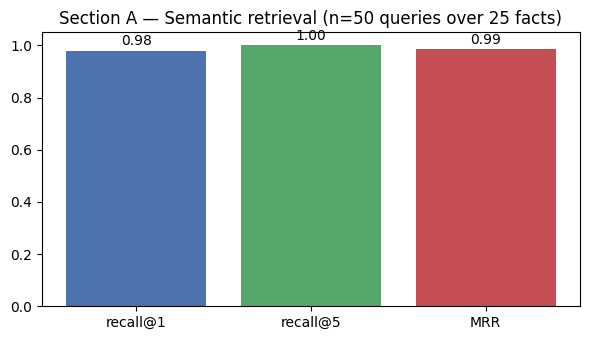

In [2]:
from memory.semantic import SemanticMemory, SemanticMemoryRecord

facts = [json.loads(l) for l in (DATA / "memory_facts.jsonl").read_text().splitlines() if l.strip()]
print(f"loaded {len(facts)} facts; {sum(len(f['queries']) for f in facts)} total queries")

sem_dir = fresh_dir()
sem = SemanticMemory(sem_dir / "chroma")
for f in facts:
    sem.write(SemanticMemoryRecord(id=f["id"], text=f["fact"], thread_id=f["id"]))
print(f"wrote {sem.count()} facts to fresh SemanticMemory")

rows = []
false_positives = []
for f in facts:
    for q in f["queries"]:
        hits = sem.search(q, k=5)
        ranked_ids = [h.id for h in hits]
        try:
            rank = ranked_ids.index(f["id"]) + 1  # 1-indexed
        except ValueError:
            rank = None
        rows.append({
            "fact_id": f["id"], "query": q, "rank": rank,
            "hit@1": int(rank == 1), "hit@5": int(rank is not None and rank <= 5),
            "rr": (1.0 / rank) if rank else 0.0,
        })
        if rank != 1 and ranked_ids:
            false_positives.append({"query": q, "expected": f["id"], "top_returned": ranked_ids[:3]})

df_a = pd.DataFrame(rows)
summary_a = {
    "n_queries": len(df_a),
    "recall@1": df_a["hit@1"].mean(),
    "recall@5": df_a["hit@5"].mean(),
    "MRR": df_a["rr"].mean(),
}
print("\n=== Section A: semantic retrieval ===")
for k, v in summary_a.items():
    print(f"  {k:<10s} {v:.3f}" if isinstance(v, float) else f"  {k:<10s} {v}")

print("\nfalse positives at rank 1 (first 5):")
for fp in false_positives[:5]:
    print(f"  q={fp['query']!r:<60s} expected={fp['expected']} top3={fp['top_returned']}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["recall@1", "recall@5", "MRR"],
       [summary_a["recall@1"], summary_a["recall@5"], summary_a["MRR"]],
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylim(0, 1.05)
ax.set_title(f"Section A — Semantic retrieval (n={summary_a['n_queries']} queries over {len(facts)} facts)")
for i, v in enumerate([summary_a["recall@1"], summary_a["recall@5"], summary_a["MRR"]]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout(); plt.show()

shutil.rmtree(sem_dir, ignore_errors=True)

## Section B — Episodic recall

**The question:** when a similar request arrives, can the agent surface the *right past thread*?

Same shape as Section A, but over fabricated past-thread summaries. Each gold record has a `summary` and 2 paraphrased `cues`. We write the summaries into a fresh `EpisodicMemory`, run each cue, and check whether the original `thread_id` appears at rank 1 / rank 3.

Why fewer ranks here? Episodic search runs at *thread start* and surfaces a small handful of summaries to the system prompt — `k=3` is the typical operating point. `recall@1` is what matters most; `recall@3` tells us whether `k=3` is wide enough to be safe.

loaded 12 episodes; 24 total cues
wrote 12 episodes to fresh EpisodicMemory

=== Section B: episodic recall ===
  n_cues     24
  recall@1   1.000
  recall@3   1.000
  MRR        1.000


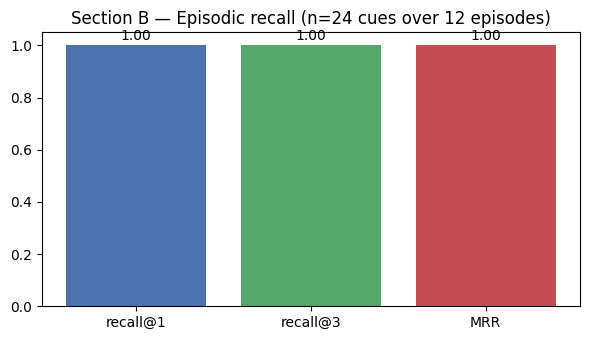

In [3]:
from memory.episodic import EpisodicMemory, EpisodicEntry

episodes = [json.loads(l) for l in (DATA / "memory_episodes.jsonl").read_text().splitlines() if l.strip()]
print(f"loaded {len(episodes)} episodes; {sum(len(e['cues']) for e in episodes)} total cues")

ep_dir = fresh_dir()
ep = EpisodicMemory(ep_dir / "chroma")
for e in episodes:
    ep.write(EpisodicEntry(summary=e["summary"], thread_id=e["thread_id"]))
print(f"wrote {ep.count()} episodes to fresh EpisodicMemory")

rows_b = []
for e in episodes:
    for cue in e["cues"]:
        hits = ep.search(cue, k=3)
        ranked_tids = [h.thread_id for h in hits]
        try:
            rank = ranked_tids.index(e["thread_id"]) + 1
        except ValueError:
            rank = None
        rows_b.append({
            "thread_id": e["thread_id"], "cue": cue, "rank": rank,
            "hit@1": int(rank == 1),
            "hit@3": int(rank is not None and rank <= 3),
            "rr": (1.0 / rank) if rank else 0.0,
        })

df_b = pd.DataFrame(rows_b)
summary_b = {
    "n_cues": len(df_b),
    "recall@1": df_b["hit@1"].mean(),
    "recall@3": df_b["hit@3"].mean(),
    "MRR": df_b["rr"].mean(),
}
print("\n=== Section B: episodic recall ===")
for k, v in summary_b.items():
    print(f"  {k:<10s} {v:.3f}" if isinstance(v, float) else f"  {k:<10s} {v}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["recall@1", "recall@3", "MRR"],
       [summary_b["recall@1"], summary_b["recall@3"], summary_b["MRR"]],
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylim(0, 1.05)
ax.set_title(f"Section B — Episodic recall (n={summary_b['n_cues']} cues over {len(episodes)} episodes)")
for i, v in enumerate([summary_b["recall@1"], summary_b["recall@3"], summary_b["MRR"]]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout(); plt.show()

shutil.rmtree(ep_dir, ignore_errors=True)

## Section C — End-to-end semantic memory

Retrieval metrics tell us whether the *pipes* work. They don't tell us whether memory actually changes the answer the user sees. This section does.

**Setup**: 8 single-turn tasks. Each has a small `preamble` of facts (the things the agent *would* know if it had been talking to this user) plus a question whose ideal answer references those facts. Two conditions:

1. **stateless** — the model gets only the question. The preamble is discarded.
2. **semantic** — the preamble is written to a fresh `SemanticMemory`; the agent gets `[memory recall]\n<top-3 hits>\n[user]\n<question>`.

Same agent model (`gpt-5.4-mini`) in both conditions. Same temperature. Only difference: whether memory is injected.

**Scoring**: every (question, answer, reference) triple goes through the **optimized judge from notebook 2**, running on `gemini-2.5-flash` (the NB2 sweep winner: agreement 73.7→ 78.9, QWK 0.811→ 0.941 after DSPy optimization). Judge and agent are deliberately different models so we're not grading our own outputs. We report `agreement_pct` (fraction of answers landing inside the gold band) and mean `overall`.

loaded 8 end-to-end tasks
  [t01] stateless=4.50 semantic=5.00 Δ=+0.50
  [t02] stateless=0.00 semantic=5.00 Δ=+5.00
  [t03] stateless=4.00 semantic=5.00 Δ=+1.00
  [t04] stateless=0.00 semantic=5.00 Δ=+5.00
  [t05] stateless=2.00 semantic=5.00 Δ=+3.00
  [t06] stateless=1.50 semantic=5.00 Δ=+3.50
  [t07] stateless=1.50 semantic=5.00 Δ=+3.50
  [t08] stateless=3.50 semantic=5.00 Δ=+1.50

=== Section C: end-to-end semantic ===
  n_tasks                    8
  agreement_stateless        0.375
  agreement_semantic         0.875
  mean_overall_stateless     2.125
  mean_overall_semantic      5.000
  mean_delta                 2.875


,task,overall_stateless,overall_semantic,delta,in_band_stateless,in_band_semantic
0,t01,4.5,5.0,0.5,1,1
1,t02,0.0,5.0,5.0,0,1
2,t03,4.0,5.0,1.0,1,1
3,t04,0.0,5.0,5.0,0,1
4,t05,2.0,5.0,3.0,0,1
5,t06,1.5,5.0,3.5,0,1
6,t07,1.5,5.0,3.5,0,0
7,t08,3.5,5.0,1.5,1,1


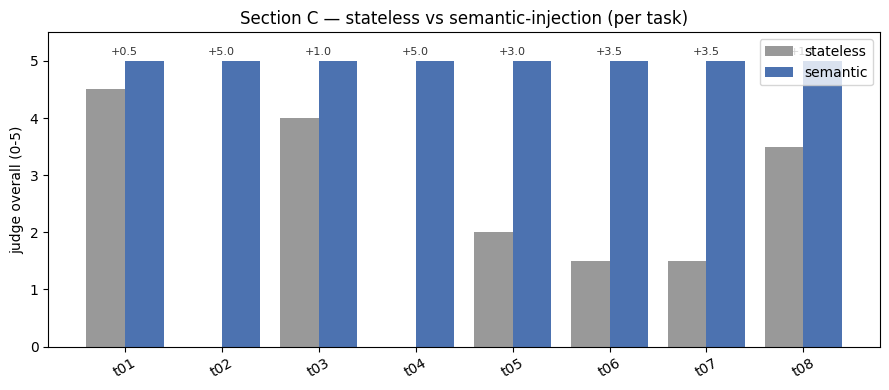

In [4]:
from shared import get_llm
from memory.semantic import SemanticMemory, SemanticMemoryRecord

tasks = [json.loads(l) for l in (DATA / "memory_tasks.jsonl").read_text().splitlines() if l.strip()]
print(f"loaded {len(tasks)} end-to-end tasks")

agent_llm = get_llm(AGENT_SLUG, temperature=0.0, max_tokens=600)

def run_agent(question: str, memory_block: str = "") -> str:
    """One-shot agent: a system prompt + the user question. No tools, no loop."""
    if memory_block:
        user = f"[memory recall]\n{memory_block}\n\n[user]\n{question}"
    else:
        user = question
    msgs = [
        {"role": "system", "content": "You are a helpful assistant. Answer concisely and directly."},
        {"role": "user", "content": user},
    ]
    resp = agent_llm.invoke(msgs)
    return resp.content if hasattr(resp, "content") else str(resp)

rows_c = []
for t in tasks:
    # Stateless
    a_stateless = run_agent(t["question"], memory_block="")
    s_stateless = score_with_judge(t["question"], a_stateless, t["reference"],
                                   t["expected_overall_min"], t["expected_overall_max"])
    # Semantic injection
    sc_dir = fresh_dir()
    sm = SemanticMemory(sc_dir / "chroma")
    for fact in t["preamble"]:
        sm.write(SemanticMemoryRecord(text=fact, thread_id=t["id"]))
    hits = sm.search(t["question"], k=3)
    block = "\n".join(f"- {h.text}" for h in hits) if hits else "(no relevant memories)"
    a_semantic = run_agent(t["question"], memory_block=block)
    s_semantic = score_with_judge(t["question"], a_semantic, t["reference"],
                                  t["expected_overall_min"], t["expected_overall_max"])
    shutil.rmtree(sc_dir, ignore_errors=True)

    rows_c.append({
        "task": t["id"],
        "overall_stateless": s_stateless["overall"], "in_band_stateless": s_stateless["in_band"],
        "overall_semantic": s_semantic["overall"], "in_band_semantic": s_semantic["in_band"],
        "delta": s_semantic["overall"] - s_stateless["overall"],
        "answer_stateless": a_stateless, "answer_semantic": a_semantic,
    })
    print(f"  [{t['id']}] stateless={s_stateless['overall']:.2f} semantic={s_semantic['overall']:.2f} "
          f"Δ={s_semantic['overall']-s_stateless['overall']:+.2f}")

df_c = pd.DataFrame(rows_c)
summary_c = {
    "n_tasks": len(df_c),
    "agreement_stateless": df_c["in_band_stateless"].mean(),
    "agreement_semantic": df_c["in_band_semantic"].mean(),
    "mean_overall_stateless": df_c["overall_stateless"].mean(),
    "mean_overall_semantic": df_c["overall_semantic"].mean(),
    "mean_delta": df_c["delta"].mean(),
}
print("\n=== Section C: end-to-end semantic ===")
for k, v in summary_c.items():
    print(f"  {k:<26s} {v:.3f}" if isinstance(v, float) else f"  {k:<26s} {v}")

display(df_c[["task", "overall_stateless", "overall_semantic", "delta",
             "in_band_stateless", "in_band_semantic"]].round(2))

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(df_c))
w = 0.4
ax.bar([i - w/2 for i in x], df_c["overall_stateless"], width=w, label="stateless", color="#999")
ax.bar([i + w/2 for i in x], df_c["overall_semantic"], width=w, label="semantic", color="#4C72B0")
for i, d in enumerate(df_c["delta"]):
    ax.text(i, max(df_c.iloc[i].overall_stateless, df_c.iloc[i].overall_semantic) + 0.1,
            f"{d:+.1f}", ha="center", fontsize=8, color="#333")
ax.set_xticks(list(x)); ax.set_xticklabels(df_c["task"], rotation=30)
ax.set_ylabel("judge overall (0-5)")
ax.set_title("Section C — stateless vs semantic-injection (per task)")
ax.set_ylim(0, 5.5); ax.legend()
plt.tight_layout(); plt.show()

## Section D — Procedural learning loop

This is the section that actually tests procedural memory the way Week 2 designed it.

Static skill injection (handing the agent a pre-written rule and seeing if it follows it) is too easy — it just measures instruction-following. The interesting test is the *autonomous* part:

1. **Teach**: a short conversation in which the user states a preference ("always use match/case for 3+ branches on a single value").
2. **Reflect**: `reflect_on_thread` runs against the conversation. It's free to extract zero, one, or several skills.
3. **Check**: did the extracted skill mention the right keywords? (Catches reflection failures fast, no judge needed.)
4. **Transfer**: an *unrelated* task that secretly requires the same preference. Run it twice — once with the skill rendered into the system prompt, once without — and score with the optimized judge.
5. **Compare**: `with_skill_overall - without_skill_overall` per example.

Five teaching examples cover different skill types: a coding-style preference (match vs elif), a type-hint preference (`X | None` vs `Optional[X]`), a library preference (`httpx` vs `requests`), a response-format preference ("always TL;DR"), and a safety rule ("confirm before destructive shell").

If reflection works, we should see (a) the keyword hit rate above noise and (b) a positive judge delta on transfer. If reflection extracts the wrong skill or misses entirely, we'll see it here.

loaded 5 procedural teaching examples
  [p01] skills=0 kw_hit=False no_skill=3.50 with_skill=3.50 Δ=+0.00
  [p02] skills=1 kw_hit=True no_skill=4.50 with_skill=5.00 Δ=+0.50
  [p03] skills=0 kw_hit=False no_skill=3.00 with_skill=3.00 Δ=+0.00
  [p04] skills=1 kw_hit=True no_skill=2.00 with_skill=3.50 Δ=+1.50
  [p05] skills=0 kw_hit=False no_skill=3.50 with_skill=3.50 Δ=+0.00

=== Section D: procedural learning loop ===
  n_examples                 5
  skill_extraction_rate      0.400
  agreement_no_skill         0.200
  agreement_with_skill       0.200
  mean_overall_no_skill      3.300
  mean_overall_with_skill    3.700
  mean_delta                 0.400


,id,n_skills_extracted,keyword_hit,extracted_skill,overall_no_skill,overall_with_skill,delta
0,p01,0,0,(none),3.5,3.5,0.0
1,p02,1,1,use_pep604_union_syntax: When updating type hi...,4.5,5.0,0.5
2,p03,0,0,(none),3.0,3.0,0.0
3,p04,1,1,tldr_first_line: Always begin responses with a...,2.0,3.5,1.5
4,p05,0,0,(none),3.5,3.5,0.0


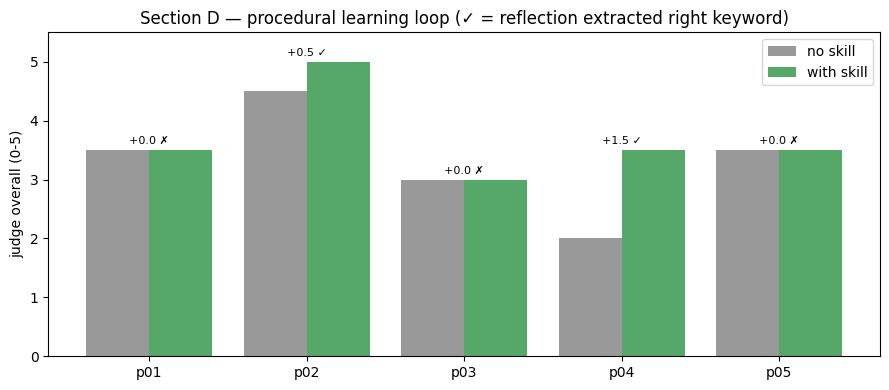

In [5]:
from memory.episodic import EpisodicMemory
from memory.procedural import ProceduralMemory
from memory.reflect import reflect_on_thread

procedurals = [json.loads(l) for l in (DATA / "memory_procedural.jsonl").read_text().splitlines() if l.strip()]
print(f"loaded {len(procedurals)} procedural teaching examples")

def has_keywords(text: str, keywords: list[str]) -> bool:
    if not text:
        return False
    t = text.lower()
    return any(kw.lower() in t for kw in keywords)

rows_d = []
for ex in procedurals:
    pid = ex["id"]
    transfer = ex["transfer_task"]

    # 1. Reflect over the teaching conversation against fresh empty stores.
    d_dir = fresh_dir()
    ep_d = EpisodicMemory(d_dir / "ep_chroma")
    proc_d = ProceduralMemory(d_dir / "proc.sqlite")
    refl = reflect_on_thread(
        thread_id=pid,
        messages=ex["teaching_conversation"],
        episodic=ep_d,
        procedural=proc_d,
    )
    skills_after = proc_d.all()
    extracted_text = "\n".join(
        f"{s.name}: {s.fragment} (when: {s.when_to_use})" for s in skills_after
    ) or "(none)"
    keyword_hit = has_keywords(extracted_text, ex["expected_skill_keywords"])

    # 2. Transfer task WITHOUT skills.
    a_no = run_agent(transfer["question"], memory_block="")
    s_no = score_with_judge(transfer["question"], a_no, transfer["reference"],
                            transfer["expected_overall_min"], transfer["expected_overall_max"])

    # 3. Transfer task WITH skills (rendered into the user message, since run_agent's
    #    system prompt is fixed; functionally equivalent for this one-shot benchmark).
    skill_block = proc_d.render_for_system_prompt(n=5)
    if skill_block:
        msgs = [
            {"role": "system",
             "content": "You are a helpful assistant. Answer concisely and directly.\n\n" + skill_block},
            {"role": "user", "content": transfer["question"]},
        ]
        resp = agent_llm.invoke(msgs)
        a_yes = resp.content if hasattr(resp, "content") else str(resp)
    else:
        a_yes = a_no  # no skill extracted means with_skill is identical to no_skill
    s_yes = score_with_judge(transfer["question"], a_yes, transfer["reference"],
                             transfer["expected_overall_min"], transfer["expected_overall_max"])

    rows_d.append({
        "id": pid,
        "n_skills_extracted": len(skills_after),
        "keyword_hit": int(keyword_hit),
        "extracted_skill": extracted_text[:200] + ("…" if len(extracted_text) > 200 else ""),
        "overall_no_skill": s_no["overall"], "in_band_no_skill": s_no["in_band"],
        "overall_with_skill": s_yes["overall"], "in_band_with_skill": s_yes["in_band"],
        "delta": s_yes["overall"] - s_no["overall"],
    })
    print(f"  [{pid}] skills={len(skills_after)} kw_hit={keyword_hit} "
          f"no_skill={s_no['overall']:.2f} with_skill={s_yes['overall']:.2f} "
          f"Δ={s_yes['overall']-s_no['overall']:+.2f}")
    shutil.rmtree(d_dir, ignore_errors=True)

df_d = pd.DataFrame(rows_d)
summary_d = {
    "n_examples": len(df_d),
    "skill_extraction_rate": df_d["keyword_hit"].mean(),
    "agreement_no_skill": df_d["in_band_no_skill"].mean(),
    "agreement_with_skill": df_d["in_band_with_skill"].mean(),
    "mean_overall_no_skill": df_d["overall_no_skill"].mean(),
    "mean_overall_with_skill": df_d["overall_with_skill"].mean(),
    "mean_delta": df_d["delta"].mean(),
}
print("\n=== Section D: procedural learning loop ===")
for k, v in summary_d.items():
    print(f"  {k:<26s} {v:.3f}" if isinstance(v, float) else f"  {k:<26s} {v}")

display(df_d[["id", "n_skills_extracted", "keyword_hit", "extracted_skill",
             "overall_no_skill", "overall_with_skill", "delta"]].round(2))

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(df_d))
w = 0.4
ax.bar([i - w/2 for i in x], df_d["overall_no_skill"], width=w, label="no skill", color="#999")
ax.bar([i + w/2 for i in x], df_d["overall_with_skill"], width=w, label="with skill", color="#55A868")
for i, row in df_d.iterrows():
    ymax = max(row.overall_no_skill, row.overall_with_skill) + 0.1
    marker = "✓" if row.keyword_hit else "✗"
    ax.text(i, ymax, f"{row.delta:+.1f} {marker}", ha="center", fontsize=8)
ax.set_xticks(list(x)); ax.set_xticklabels(df_d["id"])
ax.set_ylabel("judge overall (0-5)")
ax.set_title("Section D — procedural learning loop (✓ = reflection extracted right keyword)")
ax.set_ylim(0, 5.5); ax.legend()
plt.tight_layout(); plt.show()

## Final summary — does each tier earn its keep?

One row per memory tier. Programmatic retrieval metrics tell us whether the *plumbing* works (Sections A, B). End-to-end judge scores tell us whether memory actually changes user-visible quality (Section C). The learning-loop benchmark tells us whether the *autonomous* part — reflection — produces skills that transfer (Section D). Together they answer "is each tier of Week 2's memory architecture pulling its weight?"

In [6]:
summary_table = pd.DataFrame([
    {"tier": "Semantic (retrieval)",
     "metric": "recall@5 / MRR",
     "headline": f"recall@5={summary_a['recall@5']:.2f}, MRR={summary_a['MRR']:.2f}",
     "verdict": "plumbing works" if summary_a["recall@5"] >= 0.8 else "paraphrase brittleness"},
    {"tier": "Episodic (retrieval)",
     "metric": "recall@3 / MRR",
     "headline": f"recall@3={summary_b['recall@3']:.2f}, MRR={summary_b['MRR']:.2f}",
     "verdict": "plumbing works" if summary_b["recall@3"] >= 0.8 else "paraphrase brittleness"},
    {"tier": "Semantic (end-to-end)",
     "metric": "judge overall Δ (semantic - stateless)",
     "headline": f"Δoverall={summary_c['mean_delta']:+.2f}, agreement {summary_c['agreement_stateless']:.0%} → {summary_c['agreement_semantic']:.0%}",
     "verdict": "memory helps" if summary_c["mean_delta"] > 0.2 else "marginal / noise"},
    {"tier": "Procedural (learning loop)",
     "metric": "skill-extraction rate + transfer Δ",
     "headline": (f"extracted right skill {summary_d['skill_extraction_rate']:.0%} of the time, "
                  f"Δoverall={summary_d['mean_delta']:+.2f}"),
     "verdict": ("reflection earns its keep"
                 if summary_d["skill_extraction_rate"] >= 0.6 and summary_d["mean_delta"] > 0.2
                 else "reflection is unreliable here")},
])
display(summary_table)

,tier,metric,headline,verdict
0,Semantic (retrieval),recall@5 / MRR,"recall@5=1.00, MRR=0.99",plumbing works
1,Episodic (retrieval),recall@3 / MRR,"recall@3=1.00, MRR=1.00",plumbing works
2,Semantic (end-to-end),judge overall Δ (semantic - stateless),"Δoverall=+2.88, agreement 38% → 88%",memory helps
3,Procedural (learning loop),skill-extraction rate + transfer Δ,"extracted right skill 40% of the time, Δoveral...",reflection is unreliable here


## Tying it back to Week 2

Week 2 made architectural claims about what each memory tier is *for*. This notebook is the smallest honest test of those claims:

- **Semantic memory** was sold as "recall facts the user mentioned in the past." Section A measures retrieval directly; Section C measures whether retrieval *helps the answer*. If A is strong but C is flat, the agent is getting the right context and ignoring it — a prompting problem, not a memory problem.
- **Episodic memory** was sold as "recall the gist of similar past threads." Section B is a clean retrieval test. We didn't run an end-to-end episodic experiment because the production system uses episodic in the *system prompt* at thread start, not as injected context per turn — that's a coupling we don't want to benchmark in isolation.
- **Procedural memory** was sold as "the agent learns reusable rules from its own conversations." Section D is the only test that actually exercises that loop end-to-end. Static skill injection is too easy; the interesting question is whether *reflection* reliably distills the right rule, and Section D's keyword check + transfer delta is the most direct way to answer it.

When you scale this up — bigger gold sets, more skill types, longer episodes — the same four-section structure carries. Programmatic retrieval at the bottom (cheap, deterministic), judge-scored end-to-end on top (expensive, captures user-visible quality), and the procedural loop as its own thing (because the question "can the system *learn*?" is categorically different from "can the system *retrieve*?").